In [1]:
import duckdb
from pathlib import Path

STORE_DIR = Path(r"C:\Users\z3553082\AppData\Local\ciccada\ami_store")
con = duckdb.connect()

## METER

In [2]:
TABLE = "ami_meter"

list_random = con.sql(f"""
    SELECT DISTINCT site_id FROM read_parquet(
        '{(STORE_DIR / TABLE).as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
    LIMIT 20
""").df()

list_random

,site_id
0,287487597
1,292142344
2,293725281
3,296923913
4,302783274
5,306458711
6,308671616
7,750283202
8,752049276
9,767487922


In [3]:
SITE_ID = 931508817

In [4]:
def read_table(table_name, site_id=SITE_ID):
    return con.sql(f"""
        SELECT * FROM read_parquet('{(STORE_DIR / table_name).as_posix()}/dt_month=*/*.parquet',
                                    hive_partitioning=1)
        WHERE site_id = {site_id}
        ORDER BY t_stamp
    """).df()

In [5]:
df_raw = read_table("ami_meter")

In [6]:
df_raw

,site_id,device_id,circuit_id,t_stamp,year,month,V,P_kw,Q_kvar,S_kva,power_factor,current_a,energy_import_kwh,energy_export_kwh,dt_month
0,931508817,107082,515632,2025-01-01 00:00:00,2025,1,248.05,-1.483630,-0.291377,1.511972,0.962862,6.4080,0.000000,0.123636,2025-01
1,931508817,107082,515632,2025-01-01 00:05:00,2025,1,248.30,-1.568173,-0.284840,1.593832,0.968061,6.7685,0.000000,0.130681,2025-01
2,931508817,107082,515632,2025-01-01 00:10:00,2025,1,248.15,-1.626727,-0.283343,1.651219,0.970555,6.7310,0.000000,0.135561,2025-01
3,931508817,107082,515632,2025-01-01 00:15:00,2025,1,246.75,-1.829653,-0.282330,1.851308,0.976743,8.2920,0.000000,0.152471,2025-01
4,931508817,107082,515632,2025-01-01 00:20:00,2025,1,245.95,-2.062447,-0.277150,2.080985,0.982263,8.8450,0.000000,0.171871,2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73620,931508817,107082,515632,2025-11-18 06:55:00,2025,11,245.75,-0.001087,-0.404410,0.404411,0.000007,6.1525,0.007636,0.007726,2025-11
73621,931508817,107082,515632,2025-11-18 07:00:00,2025,11,244.10,0.012187,-0.402713,0.402897,0.000915,6.0255,0.007896,0.006880,2025-11
73622,931508817,107082,515632,2025-11-18 07:05:00,2025,11,242.65,0.031850,-0.397354,0.398628,0.006384,6.2885,0.008846,0.006192,2025-11
73623,931508817,107082,515632,2025-11-18 07:10:00,2025,11,242.25,0.025500,-0.437473,0.438216,0.003386,6.1535,0.008662,0.006537,2025-11


In [7]:
from datetime import timedelta

df_raw["t_stamp"] = df_raw["t_stamp"] + timedelta(hours=10)

In [8]:
df_day = df_raw[(df_raw["t_stamp"] >= "2025-02-15") & (df_raw["t_stamp"] < "2025-02-16")]

In [9]:
df_day

,site_id,device_id,circuit_id,t_stamp,year,month,V,P_kw,Q_kvar,S_kva,power_factor,current_a,energy_import_kwh,energy_export_kwh,dt_month
12811,931508817,107082,515632,2025-02-15 00:00:00,2025,2,235.15,4.022980,-0.443953,4.047402,0.987968,14.9790,0.335248,0.0,2025-02
12812,931508817,107082,515632,2025-02-15 00:05:00,2025,2,237.10,2.419770,-0.458936,2.462907,0.965278,10.5920,0.201648,0.0,2025-02
12813,931508817,107082,515632,2025-02-15 00:10:00,2025,2,237.80,2.666450,-0.415710,2.698661,0.976271,13.1295,0.222204,0.0,2025-02
12814,931508817,107082,515632,2025-02-15 00:15:00,2025,2,235.85,3.870477,-0.450407,3.896595,0.986639,16.7180,0.322540,0.0,2025-02
12815,931508817,107082,515632,2025-02-15 00:20:00,2025,2,236.45,3.935300,-0.446726,3.960575,0.987278,17.1220,0.327942,0.0,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,931508817,107082,515632,2025-02-15 23:35:00,2025,2,245.95,0.275717,-0.455760,0.532670,0.267923,2.2805,0.022976,0.0,2025-02
13095,931508817,107082,515632,2025-02-15 23:40:00,2025,2,244.55,0.666890,-0.351430,0.753820,0.782660,5.3520,0.055574,0.0,2025-02
13096,931508817,107082,515632,2025-02-15 23:45:00,2025,2,242.25,1.910053,-0.399850,1.951457,0.958017,8.1065,0.159171,0.0,2025-02
13097,931508817,107082,515632,2025-02-15 23:50:00,2025,2,240.55,1.823250,-0.409860,1.868750,0.951897,8.2810,0.151938,0.0,2025-02


In [10]:
df_day['circuit_id'].unique()

array([515632])

Text(0.5, 0, 'Timestamp')

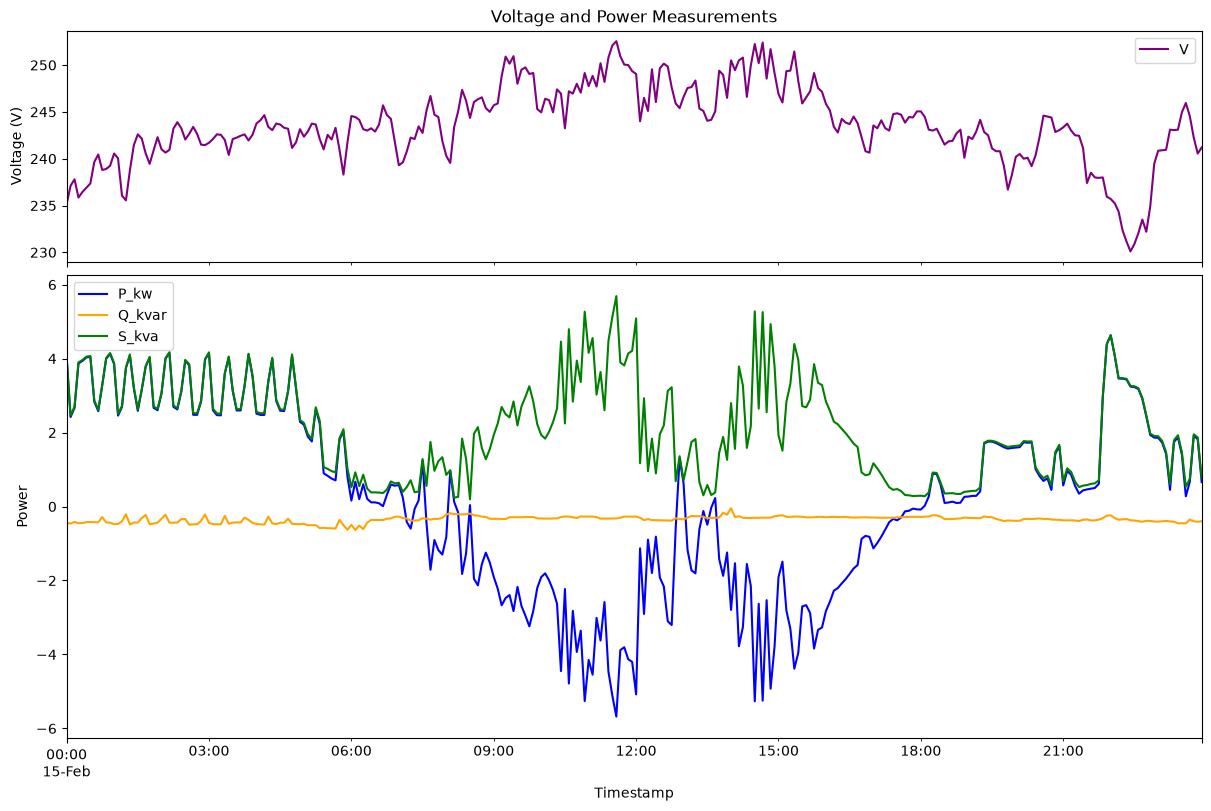

In [11]:
import matplotlib.pyplot as plt

fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day.plot(
    x="t_stamp",
    y=["P_kw", "Q_kvar", "S_kva"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

## RAW

In [12]:
df_raw = read_table("ami_raw")

In [13]:
df_raw["t_stamp"] = df_raw["t_stamp"] + timedelta(hours=10)
df_day = df_raw[(df_raw["t_stamp"] >= "2025-02-15") & (df_raw["t_stamp"] < "2025-02-16")]

In [14]:
# df_day.to_csv("df_day_ami_raw.csv", index=False)

In [15]:
df_day

,site_id,t_stamp,year,month,V_load,V_pv,P_load_kw,P_pv_kw,P_kw_norm,P_kw,Q_load_kvar,Q_pv_kvar,Q_kvar_norm,Q_kvar,S_99,ac_capacity_kw,normalization_basis,dt_month
12811,931508817,2025-02-15 00:00:00,2025,2,235.15,235.15,4.022980,-0.001017,-0.000172,4.021963,-0.443953,0.037477,0.006352,-0.406476,5.900408,6.0,s_99,2025-02
12812,931508817,2025-02-15 00:05:00,2025,2,237.10,237.20,2.419770,-0.002140,-0.000363,2.417630,-0.458936,0.038353,0.006500,-0.420583,5.900408,6.0,s_99,2025-02
12813,931508817,2025-02-15 00:10:00,2025,2,237.80,237.85,2.666450,-0.001970,-0.000334,2.664480,-0.415710,0.038617,0.006545,-0.377093,5.900408,6.0,s_99,2025-02
12814,931508817,2025-02-15 00:15:00,2025,2,235.85,235.40,3.870477,-0.001113,-0.000189,3.869363,-0.450407,0.037894,0.006422,-0.412513,5.900408,6.0,s_99,2025-02
12815,931508817,2025-02-15 00:20:00,2025,2,236.45,235.40,3.935300,-0.001087,-0.000184,3.934213,-0.446726,0.037937,0.006430,-0.408790,5.900408,6.0,s_99,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,931508817,2025-02-15 23:35:00,2025,2,245.95,245.60,0.275717,-0.003297,-0.000559,0.272420,-0.455760,0.040916,0.006935,-0.414844,5.900408,6.0,s_99,2025-02
13095,931508817,2025-02-15 23:40:00,2025,2,244.55,244.25,0.666890,-0.003017,-0.000511,0.663873,-0.351430,0.040597,0.006880,-0.310832,5.900408,6.0,s_99,2025-02
13096,931508817,2025-02-15 23:45:00,2025,2,242.25,242.15,1.910053,-0.002083,-0.000353,1.907970,-0.399850,0.039650,0.006720,-0.360199,5.900408,6.0,s_99,2025-02
13097,931508817,2025-02-15 23:50:00,2025,2,240.55,240.20,1.823250,-0.002127,-0.000360,1.821123,-0.409860,0.039070,0.006622,-0.370790,5.900408,6.0,s_99,2025-02


In [18]:
df_day["P_kw_deNorm"] = df_day["P_pv_kw"] * df_day["S_99"]
df_day["Q_kvar_deNorm"] = df_day["Q_pv_kvar"] * df_day["S_99"]

Text(0.5, 0, 'Timestamp')

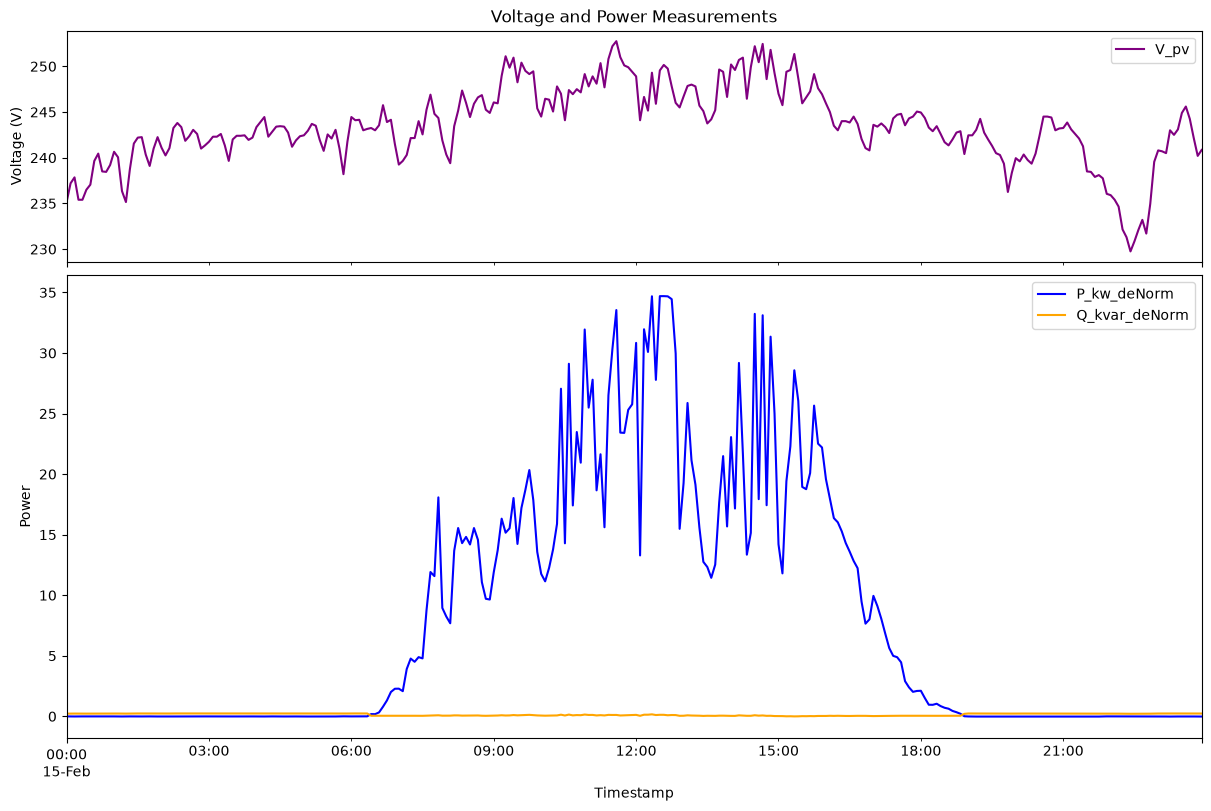

In [20]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day.plot(
    x="t_stamp",
    y="V_pv",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day.plot(
    x="t_stamp",
    y=["P_kw_deNorm", "Q_kvar_deNorm"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

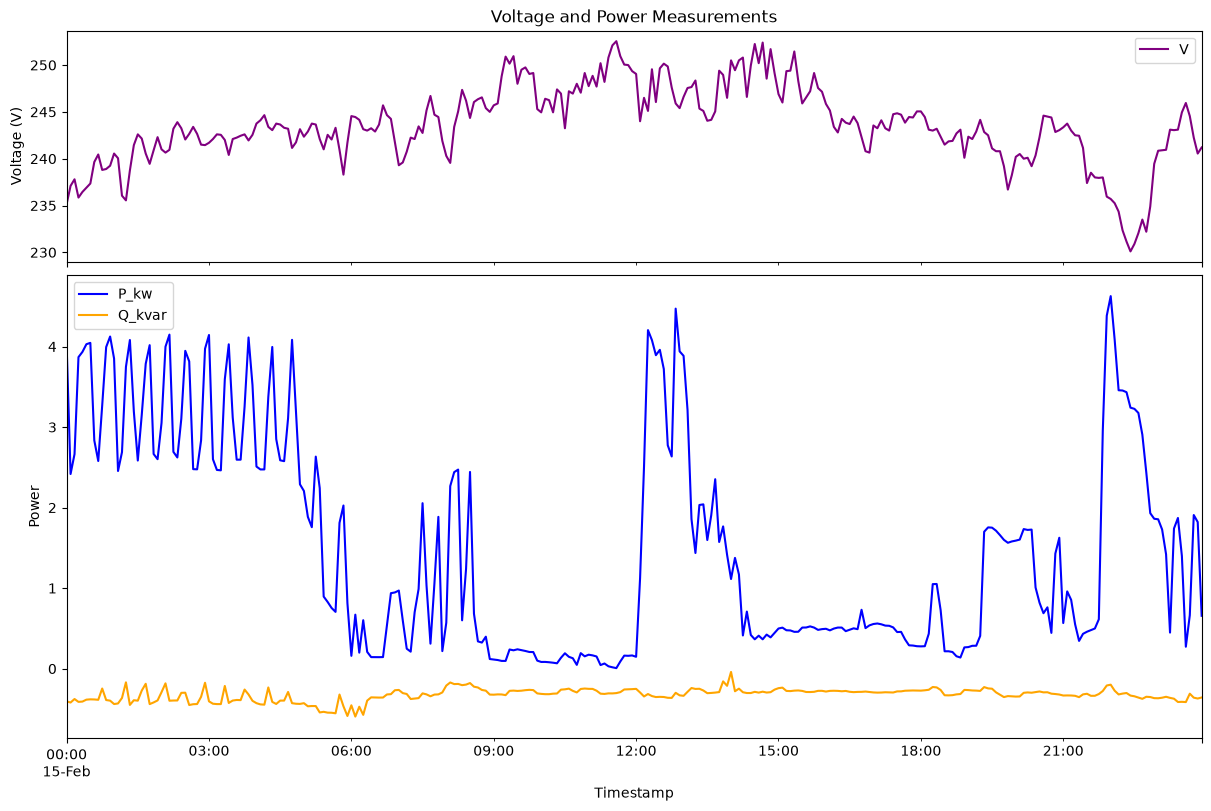

In [ ]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day.plot(
    x="t_stamp",
    y=["P_kw", "Q_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

In [ ]:
df_day["P_house_load_kw"] = df_day["P_kw"] - df_day["P_kw_deNorm"]
df_day["Q_house_load_kvar"] = df_day["Q_kvar"] - df_day["Q_kvar_deNorm"]

Text(0.5, 0, 'Timestamp')

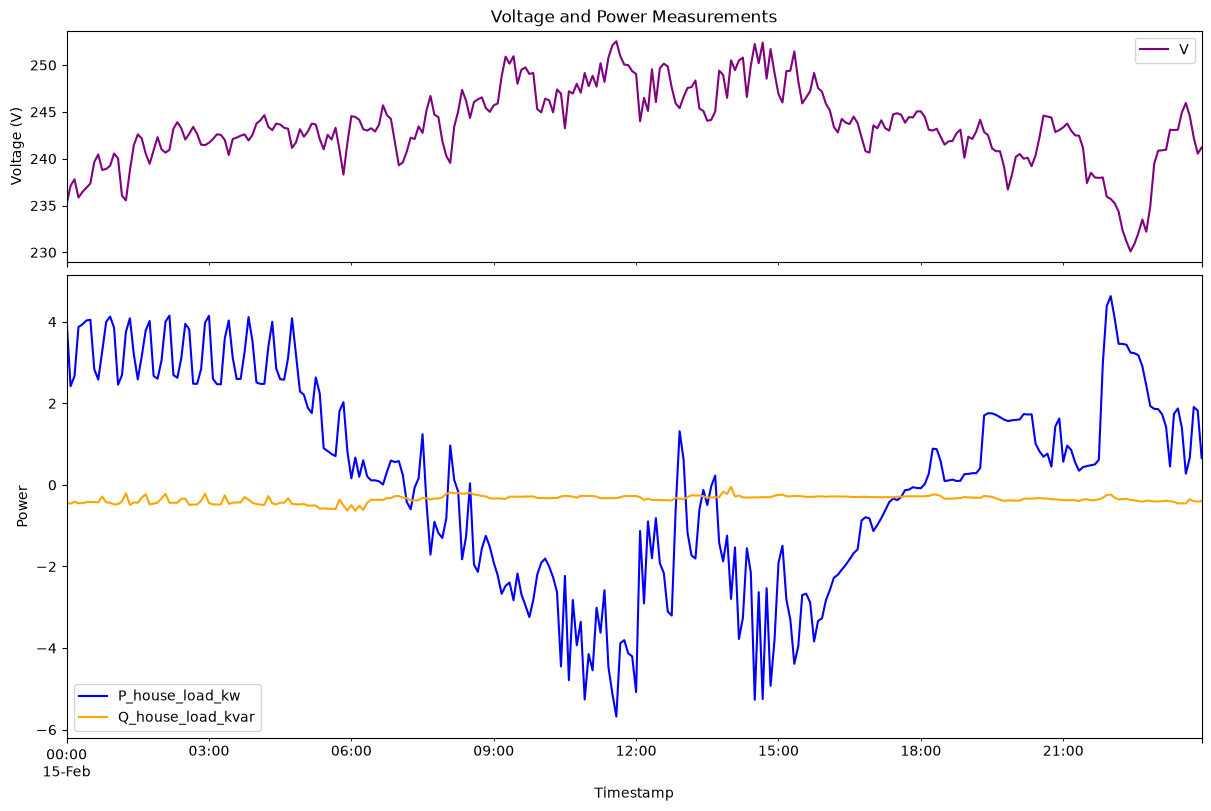

In [ ]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day.plot(
    x="t_stamp",
    y=["P_house_load_kw", "Q_house_load_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

# TS RAW

In [ ]:
from pathlib import Path

import duckdb

base_path = Path(
    r"C:\Users\z3553082\AppData\Local\ciccada\ami_store\ami_extract"
)
parquet_pattern = (
    f"{base_path.as_posix()}/dt_month=*/part-load-*"
)

columns = duckdb.query(f"""
    SELECT *
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    LIMIT 5
""").df().columns

print(columns)

In [ ]:
site_id = "360624571"
circuit_id = 515629
month = "2025-03"

In [ ]:
query = f"""
    SELECT *
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    WHERE dt_month = '2025-07'
      AND circuit_id = 515629
    ORDER BY t_stamp
"""

july_df = duckdb.query(query).df()

print(july_df.shape)
july_df.head()

In [ ]:
duckdb.query(f"""
    SELECT DISTINCT circuit_id
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    ORDER BY circuit_id
    LIMIT 50
""").df()